In [11]:
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
import os
import shap
import time

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150

sys.path.append(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection')

from src.fraud_utils import (
    engineer_features, engineer_features_xgb,
    CAT_COLS, BINARY_COLS_LR, BINARY_COLS_XGB, PASSTHROUGH_COLS_XGB,
    get_feature_names_lr, get_feature_names_xgb,
    evaluate_model
)

os.chdir(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection')


In [2]:
pipeline_lr  = joblib.load('models/pipeline_lr.pkl')
pipeline_xgb = joblib.load('models/pipeline_xgb.pkl')
pipeline_if  = joblib.load('models/pipeline_if.pkl')

X_train, y_train = joblib.load('data/train_set.pkl')
X_val,   y_val   = joblib.load('data/val_set.pkl')
feature_names    = joblib.load('models/feature_names.pkl')

print(f"X_train: {X_train.shape} | y_train fraud rate: {y_train.mean():.4f}")
print(f"X_val:   {X_val.shape}   | y_val   fraud rate: {y_val.mean():.4f}")

assert X_train.shape == (699975, 19), f"Train shape mismatch: {X_train.shape}"
assert X_val.shape[0]  == 150025,     f"Val row mismatch: {X_val.shape}"
assert X_val.shape[1]  == 19,         f"Val col mismatch: {X_val.shape}"
assert abs(y_train.mean() - 0.0553) < 0.001
assert abs(y_val.mean()   - 0.0553) < 0.001
assert 'failed_attempts' in X_train.columns
assert 'is_fraud' not in X_train.columns

for name, pipeline in [('LR', pipeline_lr), ('XGB', pipeline_xgb), ('IF', pipeline_if)]:
    steps = [s[0] for s in pipeline.steps]
    print(f"{name} pipeline steps: {steps}")

print("\n✅ All Stage 5 setup assertions passed.")


X_train: (699975, 19) | y_train fraud rate: 0.0553
X_val:   (150025, 19)   | y_val   fraud rate: 0.0553
LR pipeline steps: ['engineer', 'preprocessor', 'model']
XGB pipeline steps: ['engineer', 'preprocessor', 'model']
IF pipeline steps: ['engineer', 'preprocessor', 'model']

✅ All Stage 5 setup assertions passed.


In [3]:
lr_probs = pipeline_lr.predict_proba(X_val)[:, 1]
lr_results = evaluate_model('Logistic Regression', y_val, lr_probs)

# Store scalar values used in comparison tables below
lr_auc_pr  = lr_results['AUC_PR']
lr_auc_roc = lr_results['AUC_ROC']
lr_f1      = lr_results['F1']
lr_lift    = lr_results['Lift_10pct']
lr_fraud_captured = int(lr_results['Fraud_10pct'] / 100 * y_val.sum())



── Logistic Regression ────────────────────────────────────
  Precision  : 0.1103
  Recall     : 0.5924
  F1         : 0.1859
  AUC-ROC    : 0.7220
  AUC-PR     : 0.1246
  Lift@10%  : 2.65x
  Fraud@10% : 26.53%
  Legit/Fraud: 8.1x  (39,626 legitimate disrupted per 4,911 fraud caught)


In [4]:
lr_feature_names = get_feature_names_lr(pipeline_lr)
lr_coefs = pipeline_lr.named_steps['model'].coef_[0]

assert len(lr_feature_names) == len(lr_coefs), \
    f"Mismatch — names: {len(lr_feature_names)}, coefs: {len(lr_coefs)}"

coef_df = pd.DataFrame({
    'feature'    : lr_feature_names,
    'coefficient': lr_coefs
}).sort_values('coefficient', ascending=False).reset_index(drop=True)

print("── Top 15 Fraud-Positive Features ───────────────────────────────────")
print(coef_df.head(15).to_string(index=False))
print("\n── Top 10 Fraud-Negative Features ───────────────────────────────────")
print(coef_df.tail(10).to_string(index=False))


── Top 15 Fraud-Positive Features ───────────────────────────────────
                    feature  coefficient
        compound_risk_score     0.797391
           is_international     0.241090
       pin_changed_recently     0.170014
         high_risk_attempts     0.128242
     high_value_transaction     0.062743
       is_night_transaction     0.056786
     merchant_category_Fuel     0.017602
   merchant_category_Gaming     0.016030
            account_balance     0.014840
   transaction_freq_monthly     0.007479
                 is_weekend     0.005657
            failed_attempts     0.005383
      num_prev_transactions     0.004751
         transaction_amount     0.001174
merchant_category_Education     0.000091

── Top 10 Fraud-Negative Features ───────────────────────────────────
                    feature  coefficient
      payment_method_Crypto    -0.037804
merchant_category_Utilities    -0.038676
             country_France    -0.050742
        device_type_Desktop    -0.05184

In [5]:
xgb_probs = pipeline_xgb.predict_proba(X_val)[:, 1]
xgb_results = evaluate_model('XGBoost V1 (compound features)', y_val, xgb_probs)

xgb_auc_pr  = xgb_results['AUC_PR']
xgb_auc_roc = xgb_results['AUC_ROC']
xgb_f1      = xgb_results['F1']
xgb_lift    = xgb_results['Lift_10pct']
xgb_fraud_captured = int(xgb_results['Fraud_10pct'] / 100 * y_val.sum())



── XGBoost V1 (compound features) ─────────────────────────
  Precision  : 0.1040
  Recall     : 0.6217
  F1         : 0.1782
  AUC-ROC    : 0.7193
  AUC-PR     : 0.1216
  Lift@10%  : 2.59x
  Fraud@10% : 25.93%
  Legit/Fraud: 8.6x  (44,413 legitimate disrupted per 5,154 fraud caught)


In [12]:
# Inspect output shape to confirm feature count
sample = X_val.iloc[:100]
engineer_step        = pipeline_xgb.named_steps['engineer']
sample_eng           = engineer_step.transform(sample)
preprocessor_xgb_v1 = pipeline_xgb.named_steps['preprocessor']
sample_processed     = preprocessor_xgb_v1.transform(sample_eng)
print(f"Preprocessor output shape: {sample_processed.shape}")

xgb_model_v1 = pipeline_xgb.named_steps['model']

# V1 binary cols = BINARY_COLS_LR (8) — V1 used full engineer_features
# V1 pass_num = PASSTHROUGH_COLS_XGB (11) — compound_risk_score fell into remainder and was dropped
ohe_v1 = preprocessor_xgb_v1.named_transformers_['ohe']
xgb_feature_names_v1 = (
    ohe_v1.get_feature_names_out(CAT_COLS).tolist()
    + BINARY_COLS_LR
    + PASSTHROUGH_COLS_XGB
)

assert len(xgb_feature_names_v1) == xgb_model_v1.n_features_in_, \
    f"Mismatch: {len(xgb_feature_names_v1)} vs {xgb_model_v1.n_features_in_}"

importance_df = pd.DataFrame({
    'feature'   : xgb_feature_names_v1,
    'importance': xgb_model_v1.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n── XGBoost V1 Feature Importance — Top 20 ───────────────────────────")
print(importance_df.head(20).to_string(index=False))

engineered = ['high_risk_attempts', 'night_international', 'high_risk_merchant',
              'compound_risk_score', 'high_value_transaction']
eng_imp = importance_df[importance_df['feature'].isin(engineered)]['importance'].sum()
raw_imp = importance_df[~importance_df['feature'].isin(engineered)]['importance'].sum()
print(f"\nEngineered features: {eng_imp:.4f} ({eng_imp*100:.1f}%)")
print(f"Raw features       : {raw_imp:.4f} ({raw_imp*100:.1f}%)")

Preprocessor output shape: (100, 55)

── XGBoost V1 Feature Importance — Top 20 ───────────────────────────
                        feature  importance
             high_risk_attempts    0.260486
           is_night_transaction    0.238560
               is_international    0.138180
             high_risk_merchant    0.119677
           pin_changed_recently    0.038723
        time_since_last_txn_hrs    0.008653
                device_type_ATM    0.004667
                   credit_score    0.004641
   payment_method_Bank Transfer    0.004582
merchant_category_Entertainment    0.004388
      payment_method_Debit Card    0.004380
             transaction_amount    0.004362
     payment_method_Credit Card    0.004339
              account_age_years    0.004322
                    country_USA    0.004314
                   customer_age    0.004308
                 country_Brazil    0.004307
         merchant_category_Fuel    0.004273
     merchant_category_Clothing    0.004262
       merch

In [13]:
preprocessor_xgb_v2 = ColumnTransformer(
    transformers=[
        ('ohe',         OneHotEncoder(handle_unknown='ignore',
                                      sparse_output=False), CAT_COLS),
        ('pass_binary', 'passthrough',                      BINARY_COLS_XGB),
        ('pass_num',    'passthrough',                      PASSTHROUGH_COLS_XGB),
    ],
    remainder='drop'
)

pipeline_xgb_v2 = Pipeline([
    ('engineer',     FunctionTransformer(engineer_features_xgb, validate=False)),
    ('preprocessor', preprocessor_xgb_v2),
    ('model', XGBClassifier(
        scale_pos_weight=17,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='aucpr',
        n_jobs=-1
    ))
])

print("Fitting XGBoost V2 (revised features)...")
t0 = time.time()
pipeline_xgb_v2.fit(X_train, y_train)
print(f"Done — {time.time()-t0:.0f}s")

sample_eng_v2  = engineer_features_xgb(X_val.iloc[:10])
sample_proc_v2 = preprocessor_xgb_v2.transform(sample_eng_v2)
print(f"V2 preprocessor output: {sample_proc_v2.shape[1]} features (expected 53)")


Fitting XGBoost V2 (revised features)...
Done — 16s
V2 preprocessor output: 53 features (expected 53)


In [14]:
xgb_v2_probs = pipeline_xgb_v2.predict_proba(X_val)[:, 1]
xgb_v2_results = evaluate_model('XGBoost V2 (clean features)', y_val, xgb_v2_probs)

xgb_v2_auc_pr  = xgb_v2_results['AUC_PR']
xgb_v2_auc_roc = xgb_v2_results['AUC_ROC']
xgb_v2_f1      = xgb_v2_results['F1']
xgb_v2_lift    = xgb_v2_results['Lift_10pct']
xgb_v2_fraud_captured = int(xgb_v2_results['Fraud_10pct'] / 100 * y_val.sum())

print(f"\n── V1 vs V2 Comparison ───────────────────────────────────────────────")
print(f"  {'Model':<28} {'AUC-PR':>8} {'AUC-ROC':>8} {'F1':>8} {'Lift@10%':>10}")
print(f"  {'─'*28} {'─'*8} {'─'*8} {'─'*8} {'─'*10}")
print(f"  {'XGBoost V1 (compound)':<28} {xgb_auc_pr:>8.4f} {xgb_auc_roc:>8.4f} {xgb_f1:>8.4f} {xgb_lift:>9.2f}x")
print(f"  {'XGBoost V2 (clean)':<28} {xgb_v2_auc_pr:>8.4f} {xgb_v2_auc_roc:>8.4f} {xgb_v2_f1:>8.4f} {xgb_v2_lift:>9.2f}x")



── XGBoost V2 (clean features) ────────────────────────────
  Precision  : 0.1070
  Recall     : 0.6116
  F1         : 0.1821
  AUC-ROC    : 0.7202
  AUC-PR     : 0.1210
  Lift@10%  : 2.60x
  Fraud@10% : 26.00%
  Legit/Fraud: 8.3x  (42,334 legitimate disrupted per 5,070 fraud caught)

── V1 vs V2 Comparison ───────────────────────────────────────────────
  Model                          AUC-PR  AUC-ROC       F1   Lift@10%
  ──────────────────────────── ──────── ──────── ──────── ──────────
  XGBoost V1 (compound)          0.1216   0.7193   0.1782      2.59x
  XGBoost V2 (clean)             0.1210   0.7202   0.1821      2.60x


In [15]:
X_val_eng_v2    = engineer_features_xgb(X_val)
X_val_proc_v2   = preprocessor_xgb_v2.transform(X_val_eng_v2)

X_train_eng_v2  = engineer_features_xgb(X_train)
X_train_proc_v2 = preprocessor_xgb_v2.transform(X_train_eng_v2)

print(f"Train processed: {X_train_proc_v2.shape}")
print(f"Val processed:   {X_val_proc_v2.shape}")

xgb_v3 = XGBClassifier(
    scale_pos_weight=17,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    n_jobs=-1
)

print("Fitting XGBoost V3 with early stopping...")
t0 = time.time()
xgb_v3.fit(
    X_train_proc_v2, y_train,
    eval_set=[(X_val_proc_v2, y_val)],
    verbose=50
)
print(f"\nDone — {time.time()-t0:.0f}s")
print(f"Best iteration : {xgb_v3.best_iteration}")
print(f"Best AUC-PR    : {xgb_v3.best_score:.4f}")


Train processed: (699975, 53)
Val processed:   (150025, 53)
Fitting XGBoost V3 with early stopping...
[0]	validation_0-aucpr:0.12134
[45]	validation_0-aucpr:0.12617

Done — 5s
Best iteration : 15
Best AUC-PR    : 0.1265


In [16]:
xgb_v3_probs = xgb_v3.predict_proba(X_val_proc_v2)[:, 1]
xgb_v3_results = evaluate_model('XGBoost V3 (early stopping)', y_val, xgb_v3_probs)

xgb_v3_auc_pr  = xgb_v3_results['AUC_PR']
xgb_v3_auc_roc = xgb_v3_results['AUC_ROC']
xgb_v3_f1      = xgb_v3_results['F1']
xgb_v3_lift    = xgb_v3_results['Lift_10pct']
xgb_v3_fraud_captured = int(xgb_v3_results['Fraud_10pct'] / 100 * y_val.sum())

print(f"\n── Final Model Comparison ────────────────────────────────────────────")
print(f"  {'Model':<28} {'AUC-PR':>8} {'AUC-ROC':>8} {'F1':>8} {'Lift@10%':>10} {'Fraud@10%':>10}")
print(f"  {'─'*28} {'─'*8} {'─'*8} {'─'*8} {'─'*10} {'─'*10}")
print(f"  {'SQL ADV5 (rules)':<28} {'—':>8} {'—':>8} {'—':>8} {'2.62x':>10} {'26.23%':>10}")
print(f"  {'Logistic Regression':<28} {lr_auc_pr:>8.4f} {lr_auc_roc:>8.4f} {lr_f1:>8.4f} {lr_lift:>9.2f}x {lr_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V1 (compound)':<28} {xgb_auc_pr:>8.4f} {xgb_auc_roc:>8.4f} {xgb_f1:>8.4f} {xgb_lift:>9.2f}x {xgb_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V2 (clean)':<28} {xgb_v2_auc_pr:>8.4f} {xgb_v2_auc_roc:>8.4f} {xgb_v2_f1:>8.4f} {xgb_v2_lift:>9.2f}x {xgb_v2_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V3 (early stop)':<28} {xgb_v3_auc_pr:>8.4f} {xgb_v3_auc_roc:>8.4f} {xgb_v3_f1:>8.4f} {xgb_v3_lift:>9.2f}x {xgb_v3_fraud_captured/y_val.sum()*100:>9.2f}%")



── XGBoost V3 (early stopping) ────────────────────────────
  Precision  : 0.1159
  Recall     : 0.5672
  F1         : 0.1925
  AUC-ROC    : 0.7246
  AUC-PR     : 0.1243
  Lift@10%  : 2.63x
  Fraud@10% : 26.30%
  Legit/Fraud: 7.6x  (35,858 legitimate disrupted per 4,702 fraud caught)

── Final Model Comparison ────────────────────────────────────────────
  Model                          AUC-PR  AUC-ROC       F1   Lift@10%  Fraud@10%
  ──────────────────────────── ──────── ──────── ──────── ────────── ──────────
  SQL ADV5 (rules)                    —        —        —      2.62x     26.23%
  Logistic Regression            0.1246   0.7220   0.1859      2.65x     26.53%
  XGBoost V1 (compound)          0.1216   0.7193   0.1782      2.59x     25.93%
  XGBoost V2 (clean)             0.1210   0.7202   0.1821      2.60x     26.00%
  XGBoost V3 (early stop)        0.1243   0.7246   0.1925      2.63x     26.30%


In [17]:
from sklearn.preprocessing import MinMaxScaler

if_scores = pipeline_if.decision_function(X_val)
if_probs  = MinMaxScaler().fit_transform((-if_scores).reshape(-1, 1)).ravel()

if_results = evaluate_model('Isolation Forest', y_val, if_probs)

if_auc_pr  = if_results['AUC_PR']
if_auc_roc = if_results['AUC_ROC']
if_f1      = if_results['F1']
if_lift    = if_results['Lift_10pct']
if_fraud_captured = int(if_results['Fraud_10pct'] / 100 * y_val.sum())



── Isolation Forest ───────────────────────────────────────
  Precision  : 0.1256
  Recall     : 0.1685
  F1         : 0.1439
  AUC-ROC    : 0.6499
  AUC-PR     : 0.0974
  Lift@10%  : 2.16x
  Fraud@10% : 21.63%
  Legit/Fraud: 7.0x  (9,727 legitimate disrupted per 1,397 fraud caught)


In [18]:
pipeline_xgb_final = Pipeline([
    ('engineer',     FunctionTransformer(engineer_features_xgb, validate=False)),
    ('preprocessor', preprocessor_xgb_v2),
    ('model',        xgb_v3)
])

probs_pipeline = pipeline_xgb_final.predict_proba(X_val)[:, 1]
probs_direct   = xgb_v3.predict_proba(X_val_proc_v2)[:, 1]
max_diff = np.abs(probs_pipeline - probs_direct).max()

assert max_diff < 1e-6, f"Pipeline wrapper incorrect: {max_diff}"
print(f"Max diff (pipeline vs direct): {max_diff:.10f}")
print("Predictions identical ✅")

single_prob = pipeline_xgb_final.predict_proba(X_val.iloc[[0]])[0, 1]
print(f"Single transaction test — fraud prob: {single_prob:.4f} | actual: {y_val.iloc[0]}")

joblib.dump(pipeline_xgb_final, 'models/pipeline_xgb_final.pkl')
print("models/pipeline_xgb_final.pkl saved ✅")


Max diff (pipeline vs direct): 0.0000000000
Predictions identical ✅
Single transaction test — fraud prob: 0.3450 | actual: 0
models/pipeline_xgb_final.pkl saved ✅


In [19]:
from sklearn.model_selection import train_test_split as tts

_, X_shap_proc, _, y_shap = tts(
    X_val_proc_v2, y_val,
    test_size=10000/len(y_val),
    random_state=42,
    stratify=y_val
)

shap_feature_names = get_feature_names_xgb(preprocessor_xgb_v2)
assert len(shap_feature_names) == 53, f"Feature name count mismatch: {len(shap_feature_names)}"

print(f"SHAP sample shape : {X_shap_proc.shape}")
print(f"SHAP fraud rate   : {y_shap.mean():.4f}")

print("\nComputing SHAP values...")
t0 = time.time()
explainer   = shap.TreeExplainer(xgb_v3)
shap_values = explainer.shap_values(X_shap_proc)
print(f"Done — {time.time()-t0:.0f}s")

if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature'      : shap_feature_names,
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_df['rank'] = shap_df.index + 1

print("\n── SHAP Feature Importance — Top 20 ─────────────────────────────────")
print(shap_df.head(20).to_string(index=False))


SHAP sample shape : (10000, 53)
SHAP fraud rate   : 0.0553

Computing SHAP values...
Done — 0s

── SHAP Feature Importance — Top 20 ─────────────────────────────────
                          feature  mean_abs_shap  rank
               high_risk_attempts       0.165902     1
             is_night_transaction       0.142087     2
                 is_international       0.118519     3
                      hour_of_day       0.073035     4
 merchant_category_ATM Withdrawal       0.042171     5
merchant_category_Crypto Exchange       0.040312     6
        merchant_category_Jewelry       0.038887     7
             pin_changed_recently       0.030747     8
          time_since_last_txn_hrs       0.026961     9
                  failed_attempts       0.009483    10
                     credit_score       0.001266    11
            distance_from_home_km       0.001093    12
                     customer_age       0.000952    13
                  account_balance       0.000883    14
         

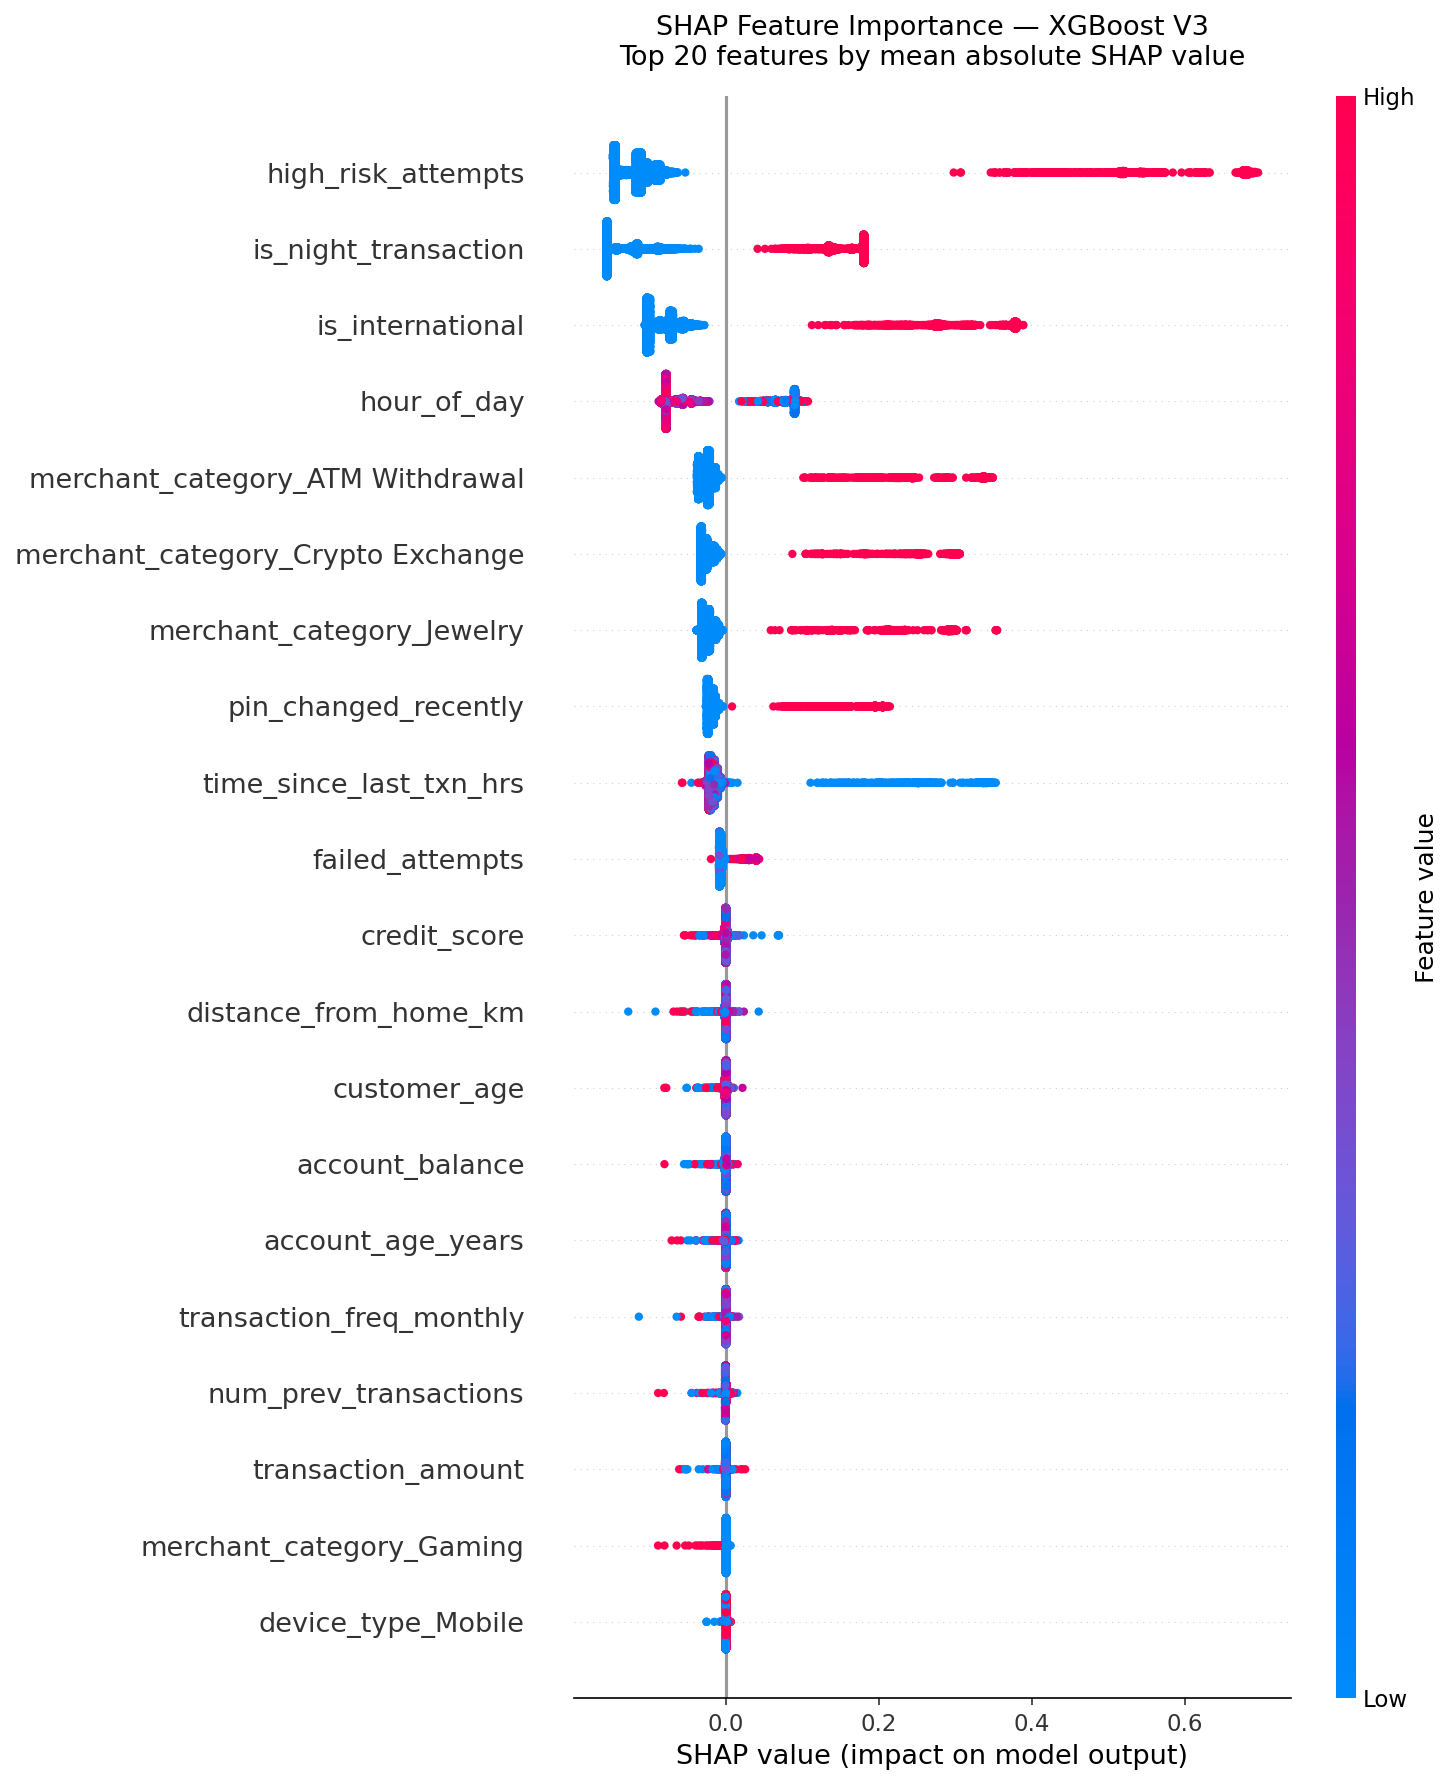

SHAP summary plot saved ✅


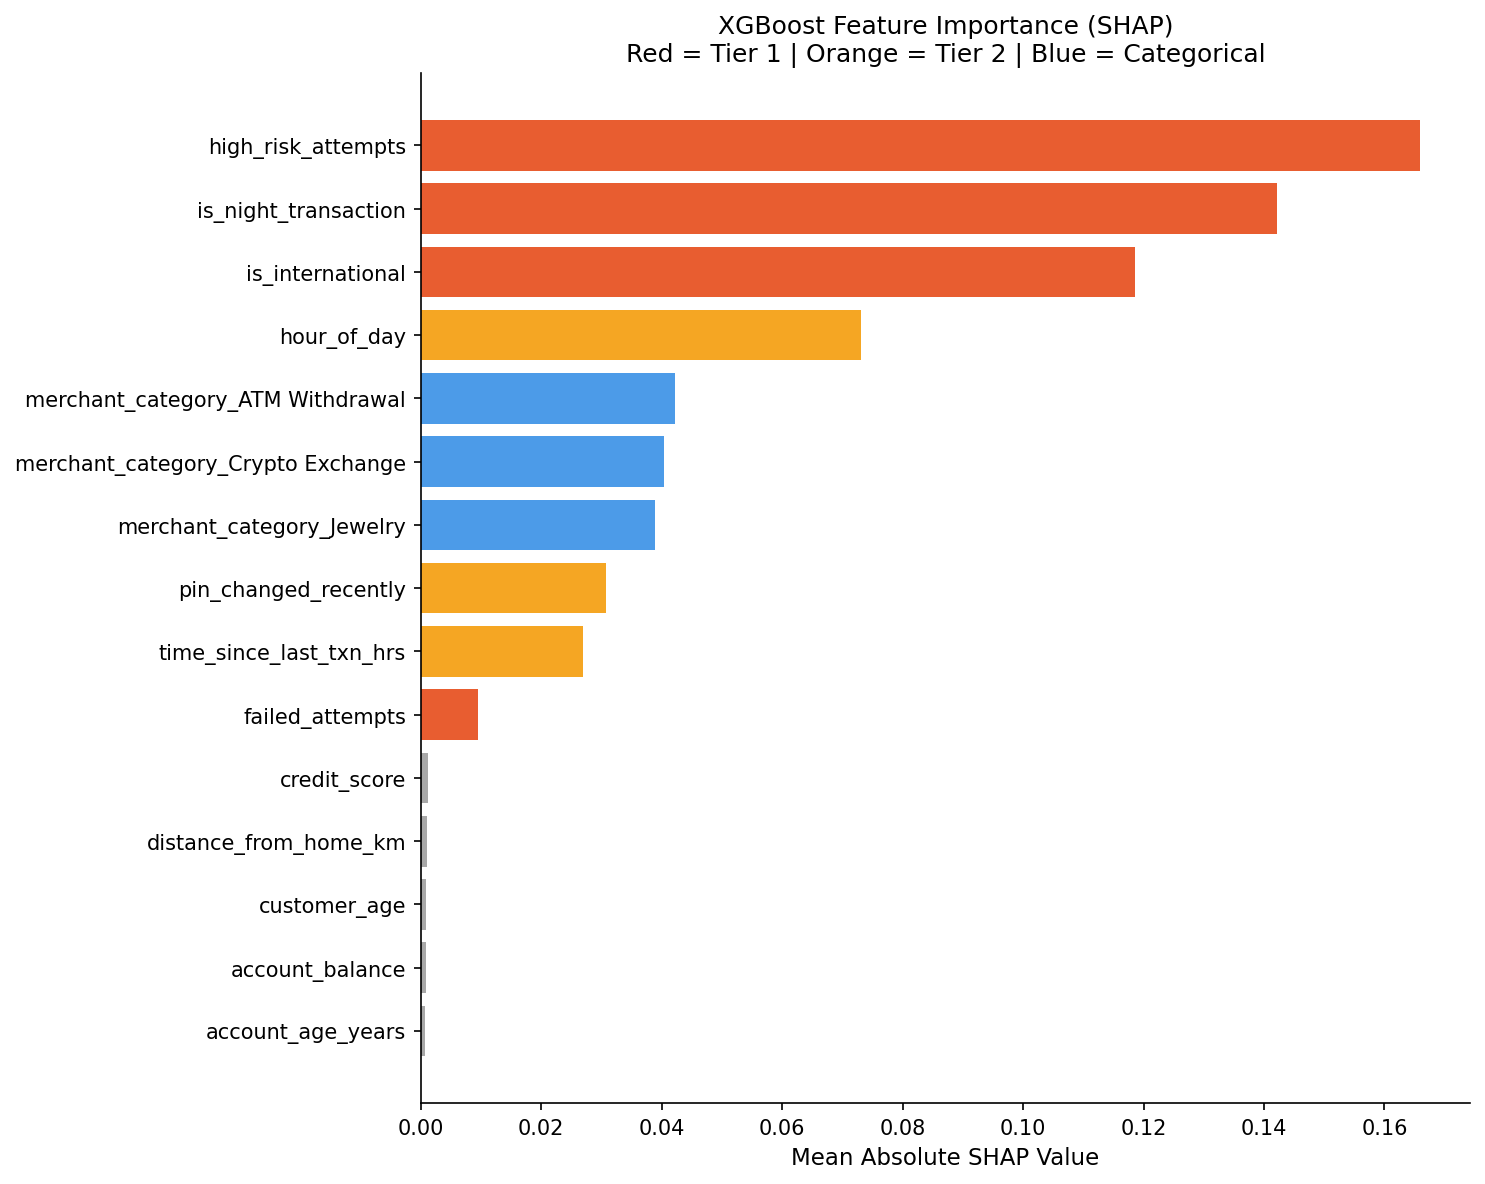

SHAP bar plot saved ✅


In [20]:
X_shap_df = pd.DataFrame(X_shap_proc, columns=shap_feature_names)

plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values, X_shap_df,
    feature_names=shap_feature_names,
    max_display=20, show=False, plot_size=None
)
plt.title('SHAP Feature Importance — XGBoost V3\nTop 20 features by mean absolute SHAP value',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('notebook/plots/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved ✅")

fig, ax = plt.subplots(figsize=(10, 8))
top15 = shap_df.head(15).iloc[::-1]

tier1 = ['high_risk_attempts', 'is_night_transaction', 'is_international', 'failed_attempts']
tier2 = ['pin_changed_recently', 'time_since_last_txn_hrs', 'hour_of_day']

colors = []
for f in top15['feature']:
    if f in tier1:
        colors.append('#E85D30')
    elif f in tier2:
        colors.append('#F5A623')
    elif f.startswith('merchant_category'):
        colors.append('#4C9BE8')
    else:
        colors.append('#A8A8A8')

ax.barh(top15['feature'], top15['mean_abs_shap'], color=colors)
ax.set_xlabel('Mean Absolute SHAP Value', fontsize=11)
ax.set_title('XGBoost Feature Importance (SHAP)\nRed = Tier 1 | Orange = Tier 2 | Blue = Categorical',
             fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('notebook/plots/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP bar plot saved ✅")


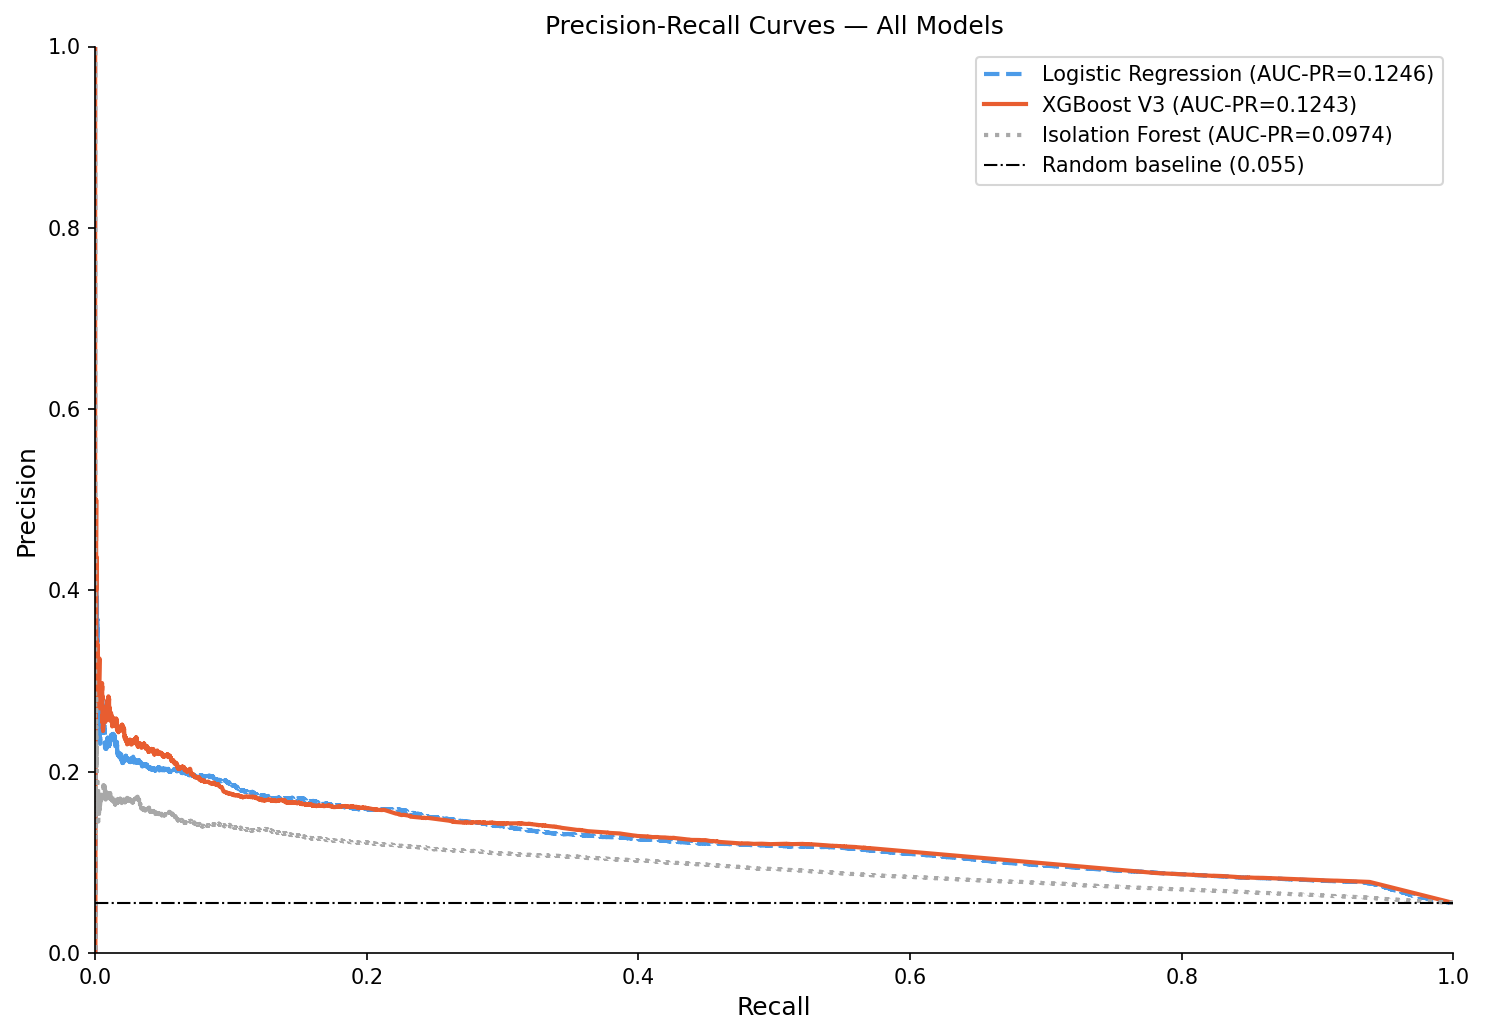

PR curves saved ✅


In [21]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(10, 7))

for name, probs, color, ls in [
    ('Logistic Regression', pipeline_lr.predict_proba(X_val)[:, 1], '#4C9BE8', '--'),
    ('XGBoost V3',          xgb_v3_probs,                           '#E85D30', '-'),
    ('Isolation Forest',    if_probs,                               '#A8A8A8', ':'),
]:
    p, r, _ = precision_recall_curve(y_val, probs)
    auc_pr  = average_precision_score(y_val, probs)
    ax.plot(r, p, label=f'{name} (AUC-PR={auc_pr:.4f})', color=color, linestyle=ls, linewidth=2)

ax.axhline(y=y_val.mean(), color='black', linestyle='-.', linewidth=1,
           label=f'Random baseline ({y_val.mean():.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('notebook/plots/pr_curves_comparison.png', dpi=150)
plt.show()
print("PR curves saved ✅")


In [22]:
joblib.dump(xgb_v3, 'models/xgb_v3_best.pkl')
joblib.dump({
    'X_train_processed': X_train_proc_v2,
    'X_val_processed'  : X_val_proc_v2,
    'feature_names'    : shap_feature_names
}, 'models/xgb_v3_processed_data.pkl')

joblib.dump({
    'lr'    : pipeline_lr.predict_proba(X_val)[:, 1],
    'xgb_v3': xgb_v3_probs,
    'if'    : if_probs,
    'y_val' : y_val.values,
}, 'models/val_scores.pkl')

joblib.dump({
    'shap_values'  : shap_values,
    'feature_names': shap_feature_names,
    'X_processed'  : X_shap_proc,
    'shap_df'      : shap_df,
}, 'models/shap_results.pkl')

pd.DataFrame({
    'Model'      : ['SQL ADV5 (rules)', 'Logistic Regression', 'XGBoost V3', 'Isolation Forest'],
    'AUC_PR'     : [None, lr_auc_pr, xgb_v3_auc_pr, if_auc_pr],
    'AUC_ROC'    : [None, lr_auc_roc, xgb_v3_auc_roc, if_auc_roc],
    'F1'         : [None, lr_f1, xgb_v3_f1, if_f1],
    'Lift_10pct' : [2.62, lr_lift, xgb_v3_lift, if_lift],
    'Fraud_10pct': [26.23,
                    lr_fraud_captured/y_val.sum()*100,
                    xgb_v3_fraud_captured/y_val.sum()*100,
                    if_fraud_captured/y_val.sum()*100],
}).to_csv('models/model_comparison.csv', index=False)

print("\n── Artifact Inventory ────────────────────────────────────────────────")
artifacts = [
    'models/pipeline_lr.pkl', 'models/pipeline_xgb_final.pkl',
    'models/pipeline_if.pkl', 'models/xgb_v3_best.pkl',
    'models/val_scores.pkl',  'models/model_comparison.csv',
    'models/shap_results.pkl','data/train_set.pkl',
    'data/val_set.pkl',       'data/test_set.pkl',
]
for path in artifacts:
    status = '✅' if os.path.exists(path) else '❌ MISSING'
    print(f"  {status}  {path}")

print("\nStage 5 complete.")



── Artifact Inventory ────────────────────────────────────────────────
  ✅  models/pipeline_lr.pkl
  ✅  models/pipeline_xgb_final.pkl
  ✅  models/pipeline_if.pkl
  ✅  models/xgb_v3_best.pkl
  ✅  models/val_scores.pkl
  ✅  models/model_comparison.csv
  ✅  models/shap_results.pkl
  ✅  data/train_set.pkl
  ✅  data/val_set.pkl
  ✅  data/test_set.pkl

Stage 5 complete.


In [1]:
import pandas as pd
import os

os.chdir(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection')

# dashboard_data.csv
dd = pd.read_csv('data/dashboard_data.csv')
print("=== dashboard_data.csv ===")
print(f"Shape: {dd.shape}")
print(f"Columns: {dd.columns.tolist()}")
print(f"Nulls:\n{dd.isnull().sum()[dd.isnull().sum() > 0]}")
print()

# shap_importance.csv
shap = pd.read_csv('data/shap_importance.csv')
print("=== shap_importance.csv ===")
print(f"Shape: {shap.shape}")
print(f"Columns: {shap.columns.tolist()}")
print(shap.to_string(index=False))
print()

# threshold_decision_table.csv
for path in ['data/threshold_decision_table.csv', 'models/threshold_decision_table.csv']:
    if os.path.exists(path):
        tdt = pd.read_csv(path)
        print(f"=== threshold_decision_table.csv ({path}) ===")
        print(f"Columns: {tdt.columns.tolist()}")
        print(tdt.to_string(index=False))
        break
else:
    print("❌ threshold_decision_table.csv not found in data/ or models/")

=== dashboard_data.csv ===
Shape: (150000, 22)
Columns: ['hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_probability', 'risk_tier']
Nulls:
Series([], dtype: int64)

=== shap_importance.csv ===
Shape: (53, 3)
Columns: ['feature', 'mean_abs_shap', 'rank']
                          feature  mean_abs_shap  rank
               high_risk_attempts       0.165902     1
             is_night_transaction       0.142087     2
                 is_international       0.118519     3
                      hour_of_day       0.073035     4
 merchant_category_ATM Withdrawal       0.042171     5
merchant_category_Crypto Exchange       0.040312     6
        me

In [2]:
import pandas as pd
dd = pd.read_csv('data/dashboard_data.csv')
print(dd['risk_tier'].value_counts())
print()
# Check what threshold was used
print("Rows with prob >= 0.60:", (dd['fraud_probability'] >= 0.60).sum())
print("Rows in Tier 1:", (dd['risk_tier'] == 'Tier 1 — Escalate').sum())

risk_tier
Tier 3 — Deprioritize       109709
Tier 2 — Standard Review     23802
Tier 1 — Escalate            16489
Name: count, dtype: int64

Rows with prob >= 0.60: 16489
Rows in Tier 1: 16489
